### MULTI INDEXES WITH PANDAS

In [6]:
import pandas as pd

# Données simulées
data = {
    ('Region', 'Pays'): ['France', 'France', 'Allemagne', 'Espagne', 'Italie'],
    ('Region', 'Ville'): ['Paris', 'Lyon', 'Berlin', 'Madrid', 'Rome'],
    ('Produit', 'Ordinateurs'): [1200, 900, 1100, 1000, 950],
    ('Produit', 'Téléphones'): [800, 700, 950, 850, 750],
    ('Produit', 'Tablettes'): [500, 400, 600, 550, 450],
}

# Création du DataFrame à en-têtes multiples
df = pd.DataFrame(data)

# Sauvegarde en Excel
df.to_excel('ventes.xlsx')

print("✅ Fichier ventes.xlsx créé avec succès !")


✅ Fichier ventes.xlsx créé avec succès !


In [7]:
# Lecture avec Pandas en précisant les deux lignes d’en-tête
df = pd.read_excel('ventes.xlsx', header=[0, 1])
print(df)
print(df.columns)


  Unnamed: 0_level_0     Region             Produit                     
  Unnamed: 0_level_1       Pays   Ville Ordinateurs Téléphones Tablettes
0                NaN        NaN     NaN         NaN        NaN       NaN
1                0.0     France   Paris      1200.0      800.0     500.0
2                1.0     France    Lyon       900.0      700.0     400.0
3                2.0  Allemagne  Berlin      1100.0      950.0     600.0
4                3.0    Espagne  Madrid      1000.0      850.0     550.0
5                4.0     Italie    Rome       950.0      750.0     450.0
MultiIndex([('Unnamed: 0_level_0', 'Unnamed: 0_level_1'),
            (            'Region',               'Pays'),
            (            'Region',              'Ville'),
            (           'Produit',        'Ordinateurs'),
            (           'Produit',         'Téléphones'),
            (           'Produit',          'Tablettes')],
           )


In [8]:
# 1️⃣ Filtrer uniquement les lignes pour la France
df_france = df[df[('Region', 'Pays')] == 'France']

# 2️⃣ Filtrer les ventes d’ordinateurs supérieures à 1000
df_pc_haut = df[df[('Produit', 'Ordinateurs')] > 1000]

# 3️⃣ Filtrer un pays et un produit spécifique
df_berlin = df[(df[('Region', 'Ville')] == 'Berlin')]


In [10]:
# Moyenne des ventes par type de produit
moyennes = df[[('Produit', 'Ordinateurs'), ('Produit', 'Téléphones'), ('Produit', 'Tablettes')]].mean()
print("Moyennes de ventes par produit :")
print(moyennes)

# Total par pays
resume = df.groupby(('Region', 'Pays'))[
    [('Produit', 'Ordinateurs'), ('Produit', 'Téléphones'), ('Produit', 'Tablettes')]
].sum()

print("\nRésumé des ventes par pays :")
print(resume)


Moyennes de ventes par produit :
Produit  Ordinateurs    1030.0
         Téléphones      810.0
         Tablettes       500.0
dtype: float64

Résumé des ventes par pays :
                   Produit                     
               Ordinateurs Téléphones Tablettes
(Region, Pays)                                 
Allemagne           1100.0      950.0     600.0
Espagne             1000.0      850.0     550.0
France              2100.0     1500.0     900.0
Italie               950.0      750.0     450.0


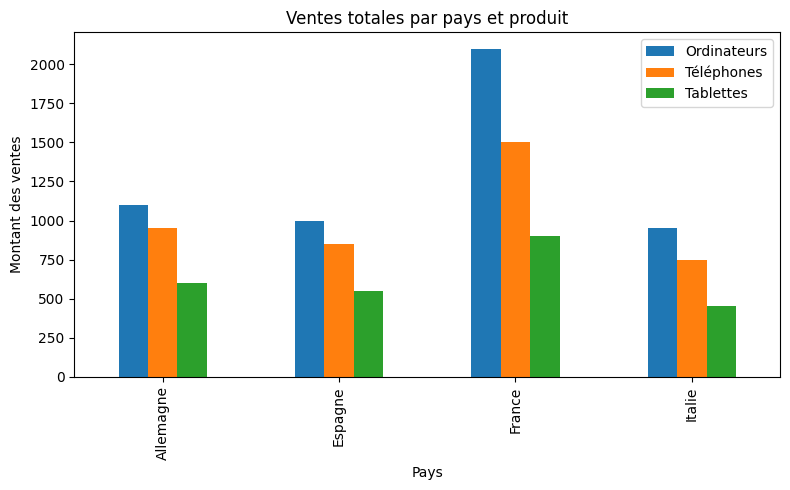

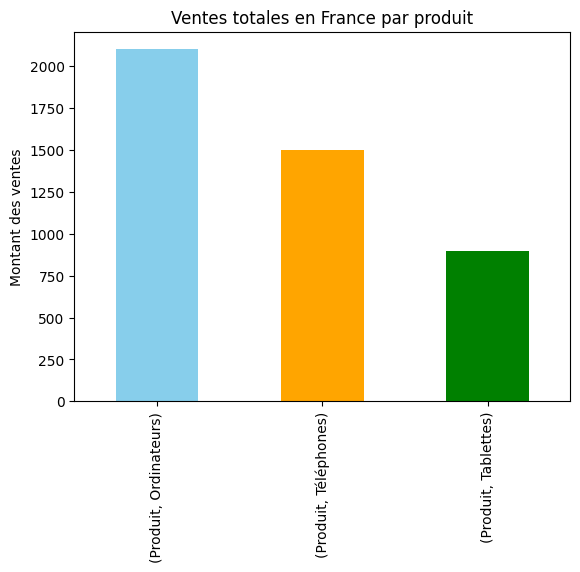

In [11]:
import matplotlib.pyplot as plt

# Ventes totales par pays et par produit
resume.plot(kind='bar', figsize=(8, 5))
plt.title("Ventes totales par pays et produit")
plt.xlabel("Pays")
plt.ylabel("Montant des ventes")
plt.legend(["Ordinateurs", "Téléphones", "Tablettes"])
plt.tight_layout()
plt.show()

# Focus sur la France
df_france_sum = df_france[[('Produit', 'Ordinateurs'), ('Produit', 'Téléphones'), ('Produit', 'Tablettes')]].sum()
df_france_sum.plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title("Ventes totales en France par produit")
plt.ylabel("Montant des ventes")
plt.show()
